### Day10 Logistic Regression [Cont.]

### Sigmoid variant of Perceptron

In [2]:
# import necessary lib.

import numpy as np

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from mlxtend.plotting import plot_decision_regions

In [3]:
X, y = make_classification(n_samples=100,
                          n_features=2,
                          n_informative=2,
                          n_redundant=0,
                          n_repeated=0,
                          n_classes=2,
                          n_clusters_per_class=2,
                          class_sep=2,
                          weights=[0.5, 0.5],
                          random_state=42)

X.shape, y.shape

((100, 2), (100,))

In [4]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
X = std_scaler.fit_transform(X)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                   random_state=42,
                                                   test_size=0.3)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((70, 2), (30, 2), (70,), (30,))

In [24]:
class SigmoidPerceptron:
    def __init__(self, epochs=50, learning_rate=1e-2):
        self.weights = None
        self.eta = learning_rate
        self.epochs = epochs

    def __sigmoid(self, z):
        return 1 / ( 1 + np.exp(-z) )

    def fit(self, X_train, y_train):
        X_train = np.c_[ ( np.ones( (X_train.shape[0], 1) ) ), X_train ]
        y_train = y_train.reshape(-1, 1)

        n_samples, n_features = X_train.shape
        self.weights = np.random.rand( n_features, 1 )

        for epoch in range(self.epochs):
            y_hat = self.__sigmoid( (X_train @ self.weights) ).reshape(-1, 1)
            gradient = ( X_train.T @ (y_train - y_hat)) / n_samples

            self.weights = self.weights + self.eta * gradient

    def predict(self, X_test):
        X_test = np.c_[ (np.ones( (X_test.shape[0], 1) )) ,X_test ]
        probs = self.__sigmoid(X_test @ self.weights)
        return (probs >= 0.5).astype(np.int32)

In [25]:
sigmoid_perceptron_clf = SigmoidPerceptron(epochs=200, learning_rate=1e-1)
sigmoid_perceptron_clf.fit(X_train, y_train)

<Axes: >

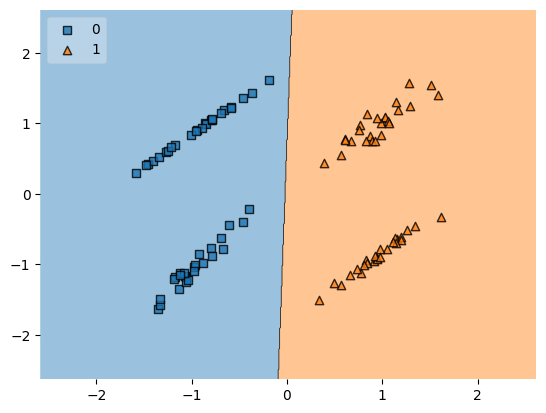

In [26]:
plot_decision_regions(X, y, clf=sigmoid_perceptron_clf, legend=2)